# Polaris Support Tickets — Synthetic Dataset v2 · EDA

**~24,000 synthetic support tickets** for *Polaris*, a fictional multichannel
analytics SaaS. Generated over a pipeline (scenario catalog → sampler → LLM),
with a **temporal event layer** on top: service **outages** (sharp spikes) and
feature **launches** (gradual waves), spread across **Jan 2024 → Jun 2026**.

This notebook verifies that the dataset has a realistic *temporal signature*
— not just balanced labels, but the clustering and seasonality real support
queues show — which is what makes it usable for triage, RAG-deflection **and**
time-series work (volume forecasting, anomaly detection).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
ACCENT, BASE_C, EVT_C = "#2E5A87", "#9db8d2", "#d9534f"

rows = [json.loads(l) for l in open("../data/tickets_v2.jsonl")]
df = pd.DataFrame(rows)
df["created_at"] = pd.to_datetime(df["created_at"])
df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()
df["is_event"] = df["event_id"].notna()
len(df), df["created_at"].min().date(), df["created_at"].max().date()

(23994, datetime.date(2024, 1, 1), datetime.date(2026, 6, 30))

## Dataset at a glance

In [ ]:
n = len(df)
ev = df["is_event"].sum()
print(f"tickets          : {n:,}")
print(f"span             : {df.created_at.min().date()} -> {df.created_at.max().date()}")
print(f"event-driven     : {ev:,} ({ev/n*100:.1f}%)   baseline flow: {n-ev:,} ({(n-ev)/n*100:.1f}%)")
print(f"unique labels    : topic={df.topic.nunique()}  type={df.type.nunique()}  "
      f"priority={df.priority.nunique()}  routing={df.routing.nunique()}  sentiment={df.sentiment.nunique()}")
print("\nby year:")
print(df.groupby(df.created_at.dt.year).size().to_string())

## 1. The temporal signature — the point of v2

Monthly volume, split into the steady **baseline flow** and the **event-driven**
tickets layered on top. A flat, memoryless generator would produce a boring
horizontal band; instead we see growth year-over-year, sharp **outage spikes**,
and broader **launch waves**.

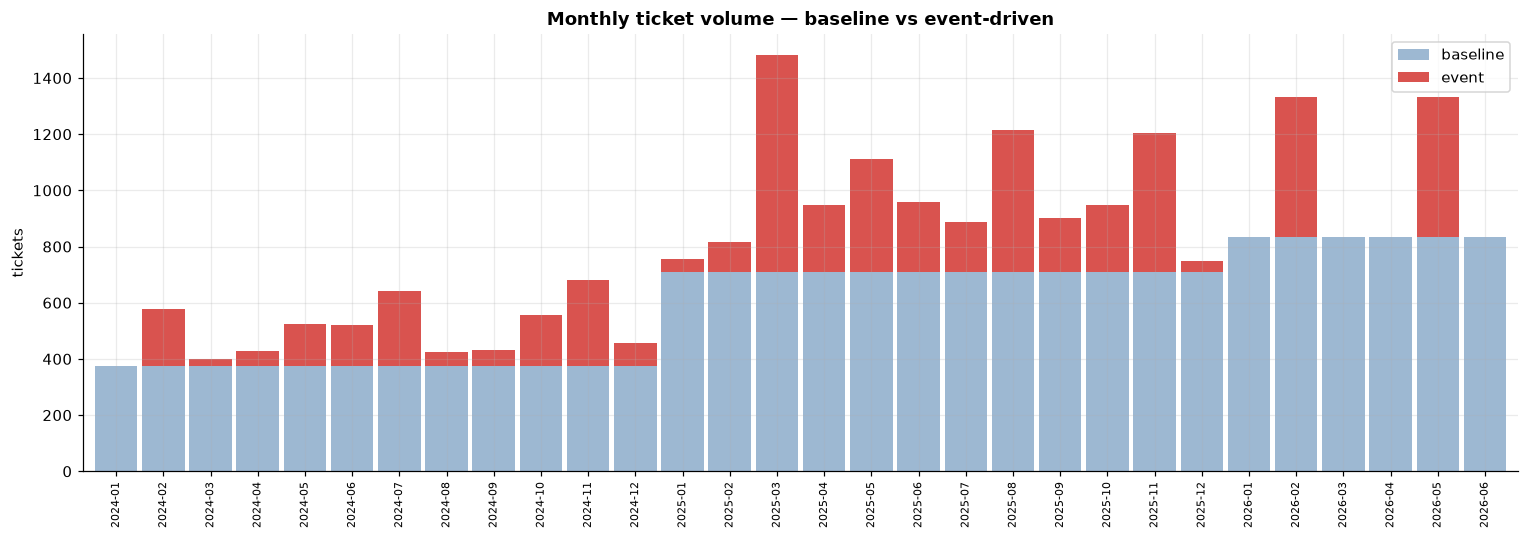

In [3]:
piv = (df.groupby(["month", "is_event"]).size()
         .unstack(fill_value=0).rename(columns={False: "baseline", True: "event"}))
# string month labels: a datetime index on a bar plot triggers a pandas Period/freq bug
piv.index = piv.index.strftime("%Y-%m")
ax = piv[["baseline", "event"]].plot(kind="bar", stacked=True, figsize=(14, 5),
                                     color=[BASE_C, EVT_C], width=0.9)
ax.set_title("Monthly ticket volume — baseline vs event-driven", fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("tickets")
ax.tick_params(axis="x", labelrotation=90); ax.tick_params(axis="x", labelsize=7)
ax.legend(title="")
plt.tight_layout(); plt.show()

**Read it:** the pale band (baseline) grows ~2x from 2024 to 2025 as the
company scales, then continues into 2026 H1. The red spikes are **outages**
(a connector or dashboards breaks → a burst of tickets in days). The wider red
build-ups are **launch waves** (a new connector ships → weeks of how-to
questions). This is exactly the clustering a real queue shows — and what a
forecasting or anomaly-detection model needs to learn from.

## 2. The launch arc — requests that vanish on launch day

Before a connector exists, customers ask *"when will you add X?"* (a
`feature_request`). The moment it ships, those requests stop and turn into
*"how do I connect X?"* (`how_to`). Plotting monthly **connector feature-requests**
with each launch date marked shows the requests building up and then dropping.

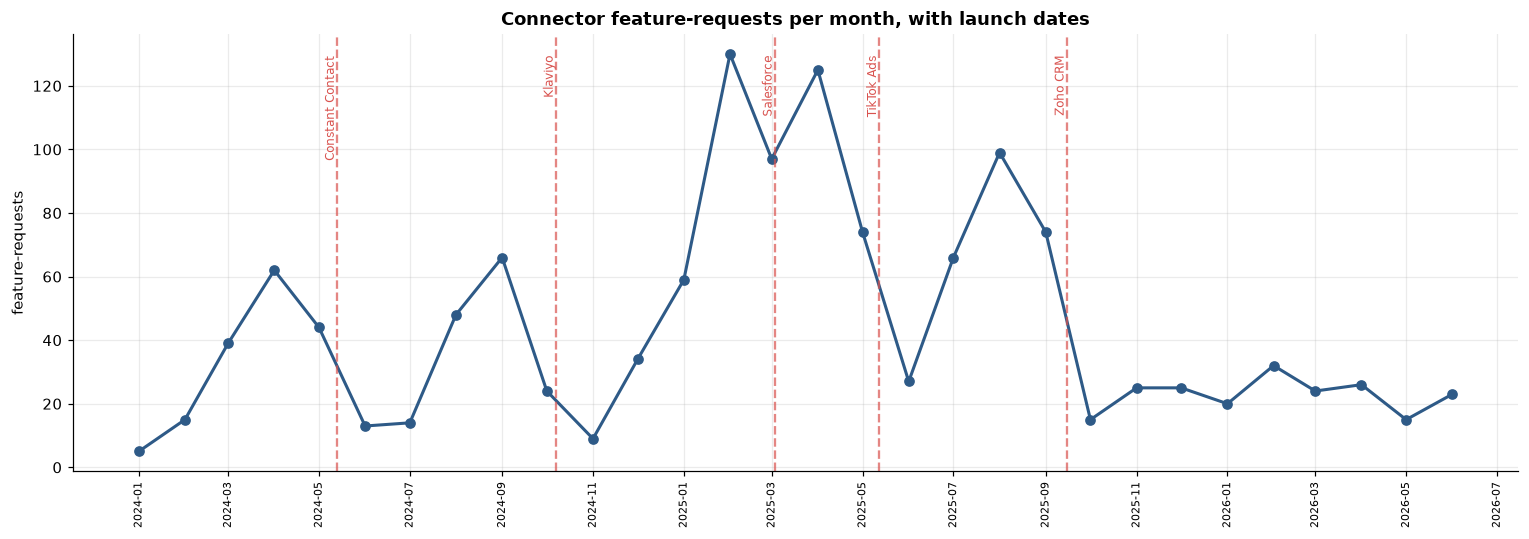

In [4]:
fr = df[(df.type == "feature_request") & (df.topic == "connectors")]
monthly_fr = fr.groupby("month").size()
launches = {"Constant Contact": "2024-05-13", "Klaviyo": "2024-10-07",
            "Salesforce": "2025-03-03", "TikTok Ads": "2025-05-12",
            "Zoho CRM": "2025-09-15"}
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_fr.index, monthly_fr.values, marker="o", color=ACCENT, lw=2)
ax.set_title("Connector feature-requests per month, with launch dates",
             fontweight="bold")
ax.set_ylabel("feature-requests"); ax.set_xlabel("")
for name, d in launches.items():
    ts = pd.Timestamp(d)
    ax.axvline(ts, color=EVT_C, ls="--", alpha=0.7)
    ax.text(ts, ax.get_ylim()[1]*0.95, name, rotation=90, va="top",
            ha="right", fontsize=8, color=EVT_C)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=90, fontsize=7); plt.tight_layout(); plt.show()

**Read it:** each dashed line is a connector going live. Notice the request
volume climbs toward a launch and collapses right after it — the demand for a
connector is *answered* by shipping it. That pivot on a known date is a clean,
learnable temporal signal (and a nice story for the dataset card).

## 3. Label distributions — the ML targets

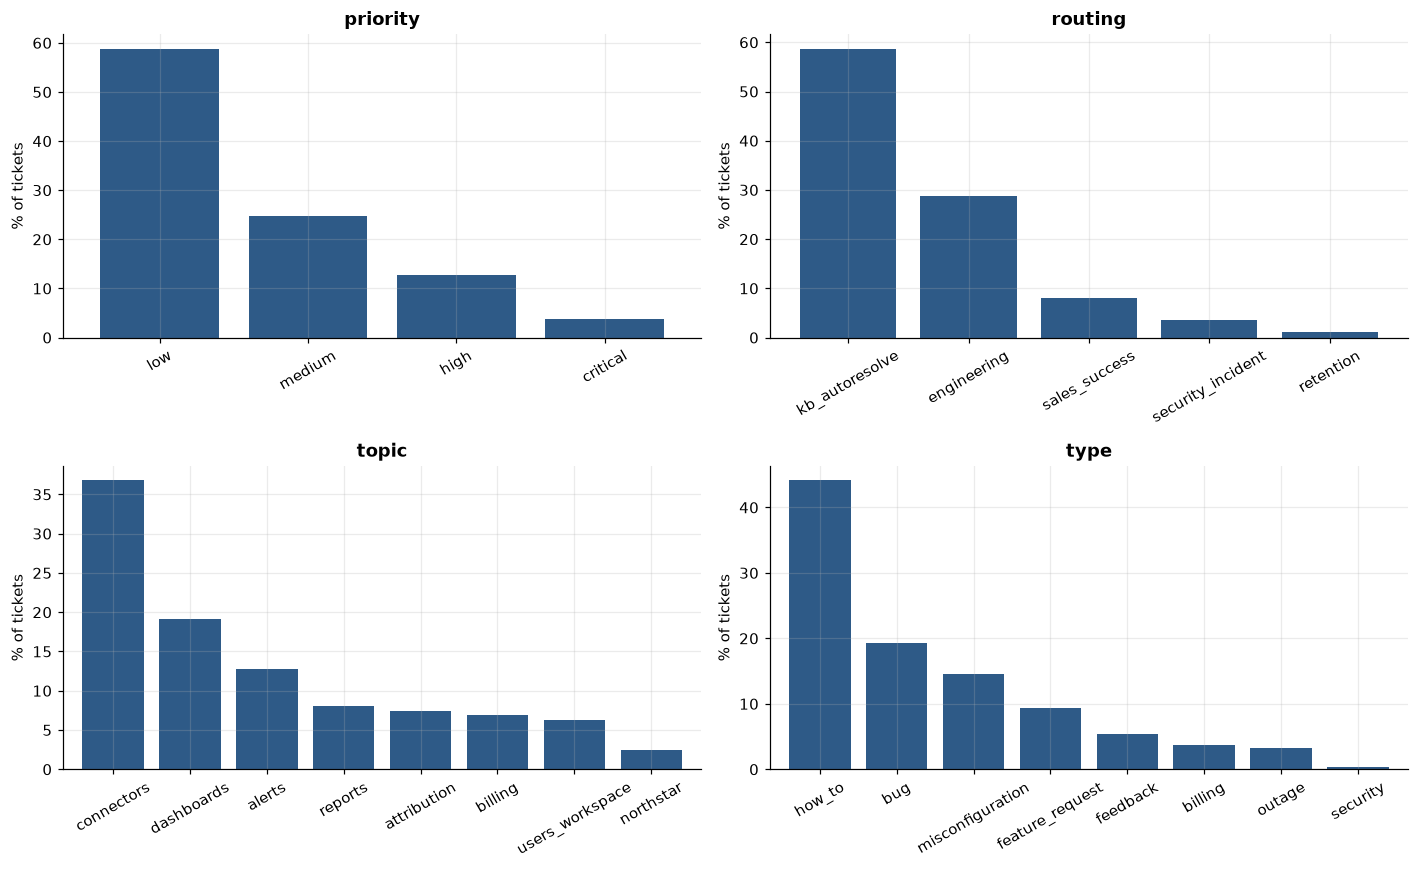

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [("priority", ["low", "medium", "high", "critical"]),
         ("routing", None), ("topic", None), ("type", None)]
for ax, (col, order) in zip(axes.ravel(), specs):
    vc = df[col].value_counts()
    if order:
        vc = vc.reindex(order)
    (vc / len(df) * 100).plot(kind="bar", ax=ax, color=ACCENT, width=0.8)
    ax.set_title(col, fontweight="bold"); ax.set_ylabel("% of tickets")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Read it:** **priority** follows a realistic long tail (most tickets are
routine, few are critical), skewed slightly toward high/critical by the outages.
**routing** is dominated by `kb_autoresolve` — the deflection opportunity the RAG
targets. **topic** and **type** stay spread across the product surface, so no
single class trivially dominates the classifier.

## 4. Sentiment — an operational prioritization signal

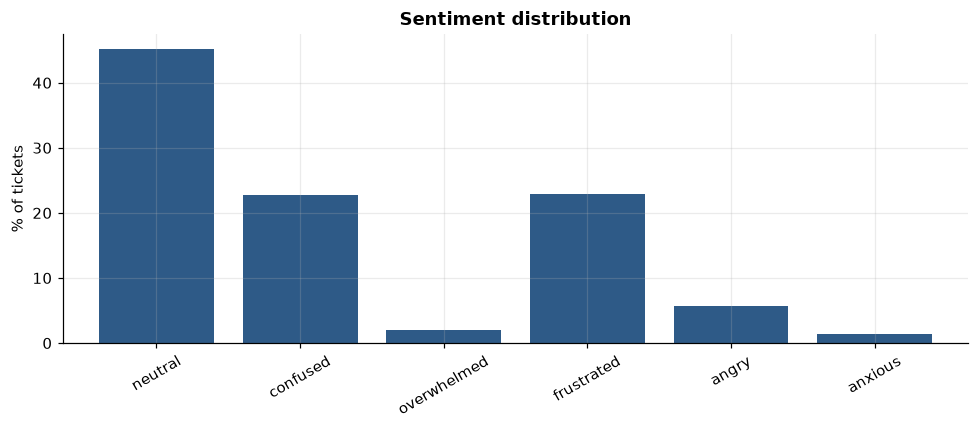

In [6]:
order = ["neutral", "confused", "overwhelmed", "frustrated", "angry", "anxious"]
vc = (df["sentiment"].value_counts().reindex(order) / len(df) * 100)
ax = vc.plot(kind="bar", figsize=(9, 4), color=ACCENT, width=0.8)
ax.set_title("Sentiment distribution", fontweight="bold")
ax.set_ylabel("% of tickets"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Read it:** sentiment is treated as an **operational** signal, not a claim
about feelings — it feeds *prioritization* (reach the angry / anxious customer
faster) and tone adaptation, so the metric that matters is recall on the
action-triggering emotions, not raw accuracy.

## 5. Message length

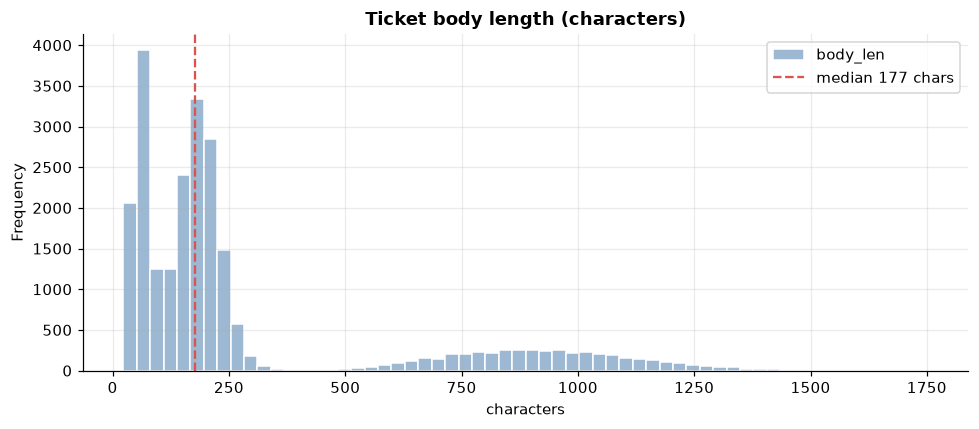

In [7]:
df["body_len"] = df["body"].fillna("").str.len()
ax = df["body_len"].plot(kind="hist", bins=60, figsize=(9, 4), color=BASE_C,
                         edgecolor="white")
ax.axvline(df.body_len.median(), color=EVT_C, ls="--",
           label=f"median {int(df.body_len.median())} chars")
ax.set_title("Ticket body length (characters)", fontweight="bold")
ax.set_xlabel("characters"); ax.legend()
plt.tight_layout(); plt.show()

**Read it:** a right-skewed spread — many terse chat messages, a long tail
of detailed emails — mirroring the length profile measured on real public
support datasets during calibration.

## What this dataset enables

- **Triage classification** — predict topic / type / priority / routing /
  sentiment from the raw text (coherent ground-truth labels by construction).
- **RAG deflection** — the `kb_autoresolve` mass is where a grounded,
  honest-refusal RAG assistant earns its keep.
- **Time-series** — the outage spikes and launch waves make volume
  **forecasting** and **anomaly detection** learnable, which a flat synthetic
  set cannot support.

*Synthetic data, generated on a real pipeline. No real users, no PII.*